# CEGO — Chat Room Monitoring
**Dataintelligence Studentermedhjælper — Case løsning**

Denne notebook dækker alle fire faser:
1. Syntetisk datasætgenerering
2. Datasætoverblik og analyse
3. AI-klassifikationssystem med handlingslogik
4. Performance-evaluering

## Fase 1 - Syntetisk datasætgenerering

Vi har ingen adgang til rigtige chatdata, så vi genererer et syntetisk datasæt via Anthropic API.

**Fordeling (500 beskeder i alt):**
- 200 normale beskeder
- 100 grimt sprog (lav / medium / høj alvorlighed)
- 100 ludomani-tegn (lav / medium / høj alvorlighed)
- 100 begge kategorier + edge cases (sarkasme, ironi, slang)

**Svaghed ved denne tilgang:** Modellen der genererer data og modellen der klassificerer deler samme træningsdata og kan have samme blinde vinkler. Syntetisk data fanger heller ikke fuldt ud den sproglige variation man ser hos rigtige brugere.

In [ ]:
import anthropic
import json
import pandas as pd
from datetime import datetime, timedelta
import random
import time

In [3]:
#API key
from dotenv import load_dotenv
import os
load_dotenv()
client = anthropic.Anthropic()

In [9]:
def generate_messages(category: str, severity: str, count: int) -> list[dict]:
    """
    Genererer syntetiske chatbeskeder via Anthropic API.
    
    Args:
        category: 'normal', 'hate_speech', 'gambling_addiction', 'both', 'edge_case'
        severity: 'none', 'low', 'medium', 'high'
        count: antal beskeder der skal genereres
    
    Returns:
        Liste af dicts med content og label-information
    """
    
    category_prompts = {
        "normal": "Almindelige, harmløse chatbeskeder fra spillere på en dansk online casino-platform. Beskeder om spil, gevinster, tips, smalltalk.",
        "hate_speech_low": "Milde ukvemsord eller lettere irritation. Ikke direkte trusler. Fx mild banden eller frustration.",
        "hate_speech_medium": "Tydelige ukvemsord, chikane mod andre brugere, eller stødende kommentarer.",
        "hate_speech_high": "Direkte trusler, grov chikane, eller meget stødende sprogbrug rettet mod andre brugere.",
        "gambling_low": "Subtile tegn på bekymrende spiladfærd. Fx nævner at de spiller meget, eller er lidt frustrerede over tab.",
        "gambling_medium": "Tydelige tegn på tab-jagt, manglende kontrol, eller bekymrende mønstre. Fx nævner store tab og vil vinde dem tilbage.",
        "gambling_high": "Klare tegn på ludomani: desperation, meget store tab, manglende kontrol, tvangsmæssig adfærd.",
        "both": "Beskeder der kombinerer grimt sprog OG tegn på ludomani. Fx en frustreret spiller der bander og nævner store tab.",
        "edge_case": "Grænsetilfælde der er svære at klassificere: sarkasme der ligner klager, ironi, slang der kan misfortolkes, uskyldig glæde over gevinst der ligner tab-jagt."
    }
    
    key = f"{category}_{severity}" if severity != "none" else category
    description = category_prompts.get(key, category_prompts["normal"])
    
    prompt = f"""Generer præcis {count} realistiske danske chatbeskeder fra et online casino chatrum.

Type: {description}

Krav:
- Skriv på dansk (inkl. dansk slang og stavemåder)
- Variér længde og stil
- Gør dem realistiske — som rigtige brugere ville skrive dem
- Ingen nummerering eller præfikser
- Brug KUN dobbelte anførselstegn i JSON, aldrig enkle

Returner KUN et JSON array med denne struktur og intet andet:
[
  {{"content": "beskedens tekst her"}},
  ...
]"""

    response = client.messages.create(
        model="claude-sonnet-4-6",
        max_tokens=4000,
        system="Du er en datalabeling-assistent der hjælper med at bygge træningsdata til et content moderation system. Dit output bruges til at træne en AI der beskytter brugere mod skadeligt indhold. Det er vigtigt at eksemplerne er realistiske og varierede, inklusive eksempler på problematisk adfærd, så systemet kan lære at genkende dem.",
        messages=[{"role": "user", "content": prompt}]
    )
    
    raw = response.content[0].text.strip()
    
    # Fjern eventuelle markdown-fences
    if raw.startswith("```"):
        raw = raw.split("\n", 1)[1].rsplit("```", 1)[0].strip()
    
    # Find JSON array eksplicit
    start = raw.find("[")
    end = raw.rfind("]") + 1
    if start == -1 or end == 0:
        raise ValueError(f"Ingen JSON array fundet i svar: {raw[:200]}")
    raw = raw[start:end]
    
    try:
        messages = json.loads(raw)
    except json.JSONDecodeError as e:
        print(f"JSON fejl: {e}")
        print(f"Råt svar (første 500 tegn): {raw[:500]}")
        raise
    
    # Tilføj labels
    label_map = {
        "normal":      {"label": "normal",      "hate_speech": False, "gambling": False, "severity": "none"},
        "hate_speech": {"label": "hate_speech",  "hate_speech": True,  "gambling": False, "severity": severity},
        "gambling":    {"label": "gambling",     "hate_speech": False, "gambling": True,  "severity": severity},
        "both":        {"label": "both",         "hate_speech": True,  "gambling": True,  "severity": severity},
        "edge_case":   {"label": "edge_case",    "hate_speech": None,  "gambling": None,  "severity": "ambiguous"},
    }
    
    labels = label_map.get(category, label_map["normal"])
    for msg in messages:
        msg.update(labels)
    
    return messages

In [10]:
# Generer alle 500 beskeder
# Vi kører i batches af 25 for at holde API-kald håndterbare

generation_plan = [
    # (category, severity, count)
    ("normal",      "none",   200),
    ("hate_speech", "low",     34),
    ("hate_speech", "medium",  33),
    ("hate_speech", "high",    33),
    ("gambling",    "low",     34),
    ("gambling",    "medium",  33),
    ("gambling",    "high",    33),
    ("both",        "medium",  50),
    ("edge_case",   "none",    50),
]

all_messages = []

for category, severity, count in generation_plan:
    print(f"Genererer {count} beskeder: {category} / {severity}...")
    
    # Kør i batches af 25
    batch_size = 25
    remaining = count
    
    while remaining > 0:
        batch = min(batch_size, remaining)
        msgs = generate_messages(category, severity, batch)
        all_messages.extend(msgs)
        remaining -= batch
        time.sleep(0.5)  # Undgå rate limiting
    
    print(f"  -> {count} beskeder genereret. Total: {len(all_messages)}")

print(f"\nDatasæt komplet: {len(all_messages)} beskeder")

Genererer 200 beskeder: normal / none...
  -> 200 beskeder genereret. Total: 200
Genererer 34 beskeder: hate_speech / low...
  -> 34 beskeder genereret. Total: 234
Genererer 33 beskeder: hate_speech / medium...
  -> 33 beskeder genereret. Total: 267
Genererer 33 beskeder: hate_speech / high...
  -> 33 beskeder genereret. Total: 300
Genererer 34 beskeder: gambling / low...
  -> 34 beskeder genereret. Total: 334
Genererer 33 beskeder: gambling / medium...
  -> 33 beskeder genereret. Total: 367
Genererer 33 beskeder: gambling / high...
  -> 33 beskeder genereret. Total: 400
Genererer 50 beskeder: both / medium...
  -> 50 beskeder genereret. Total: 450
Genererer 50 beskeder: edge_case / none...
  -> 50 beskeder genereret. Total: 500

Datasæt komplet: 500 beskeder


In [11]:
# Byg DataFrame med bruger-IDs og timestamps
random.seed(42)
n_users = 80  # 80 unikke brugere

# Shuffle så labels ikke er sorterede
random.shuffle(all_messages)

base_time = datetime(2026, 4, 13, 12, 0, 0)

rows = []
for i, msg in enumerate(all_messages):
    rows.append({
        "msg_id":      i + 1,
        "user_id":     random.randint(1, n_users),
        "content":     msg["content"],
        "timestamp":   base_time + timedelta(minutes=i * 2),
        "label":       msg["label"],
        "hate_speech": msg["hate_speech"],
        "gambling":    msg["gambling"],
        "severity":    msg["severity"],
    })

df = pd.DataFrame(rows)
df.to_csv("chat_dataset.csv", index=False)
print(f"Datasæt gemt: {len(df)} rækker")
df.head(10)

Datasæt gemt: 500 rækker


,msg_id,user_id,content,timestamp,label,hate_speech,gambling,severity
0,1,5,Nogen der kan anbefale et godt live roulette b...,2026-04-13 12:00:00,normal,False,False,none
1,2,14,tredje gang idag jeg indsætter. ved godt det e...,2026-04-13 12:02:00,gambling,False,True,high
2,3,77,"Jackpotten på Mega Fortune sidder stadig, noge...",2026-04-13 12:04:00,normal,False,False,none
3,4,56,Tip til alle: Sæt altid jeres daglige grænse i...,2026-04-13 12:06:00,normal,False,False,none
4,5,45,"Blackjack er klart det bedste her synes jeg, o...",2026-04-13 12:08:00,normal,False,False,none
5,6,41,"Appens lidt buggy på min samsung, crasher indi...",2026-04-13 12:10:00,normal,False,False,none
6,7,56,"er begyndt at kende alle dealerne på navn, tro...",2026-04-13 12:12:00,gambling,False,True,low
7,8,78,er det her rigged eller hvad for helvede,2026-04-13 12:14:00,hate_speech,True,False,low
8,9,66,"Tak for tippet med Book of Dead, er oppe med 3...",2026-04-13 12:16:00,normal,False,False,none
9,10,15,har skiftet til en slot med lavere indsats for...,2026-04-13 12:18:00,gambling,False,True,low


In [12]:
# Test om alt er rigtigt:
print(df['label'].value_counts())
print("\n")
print(df.head(3)[['content', 'label', 'severity']])

label
normal         200
gambling       100
hate_speech    100
both            50
edge_case       50
Name: count, dtype: int64


                                             content     label severity
0  Nogen der kan anbefale et godt live roulette b...    normal     none
1  tredje gang idag jeg indsætter. ved godt det e...  gambling     high
2  Jackpotten på Mega Fortune sidder stadig, noge...    normal     none


## Fase 2 - Datasæt overblik og visualiseringer

Det er her vi kigger på hvordan data ser ud, og hvordan fordelingen er.

=== Datasæt statistik ===

Antal beskeder: 500
Antal unikke brugere: 80

Gennemsnitlig beskedlængde per label (tegn):
label
both           57.5
edge_case      77.3
gambling       92.8
hate_speech    57.0
normal         62.5

Eksempler per kategori:

[normal]: Nogen der kan anbefale et godt live roulette bord? Prøver at finde et med lav minimum indsats...

[gambling]: tredje gang idag jeg indsætter. ved godt det er dumt men jackpotten er tæt på, kan mærke det...

[hate_speech]: er det her rigged eller hvad for helvede...

[both]: Hvornår plejer de at opdatere med nye spil?...

[edge_case]: Nogen der ved hvornår bettingbonussen udløber? Spørger for en ven der er lidt desperat...


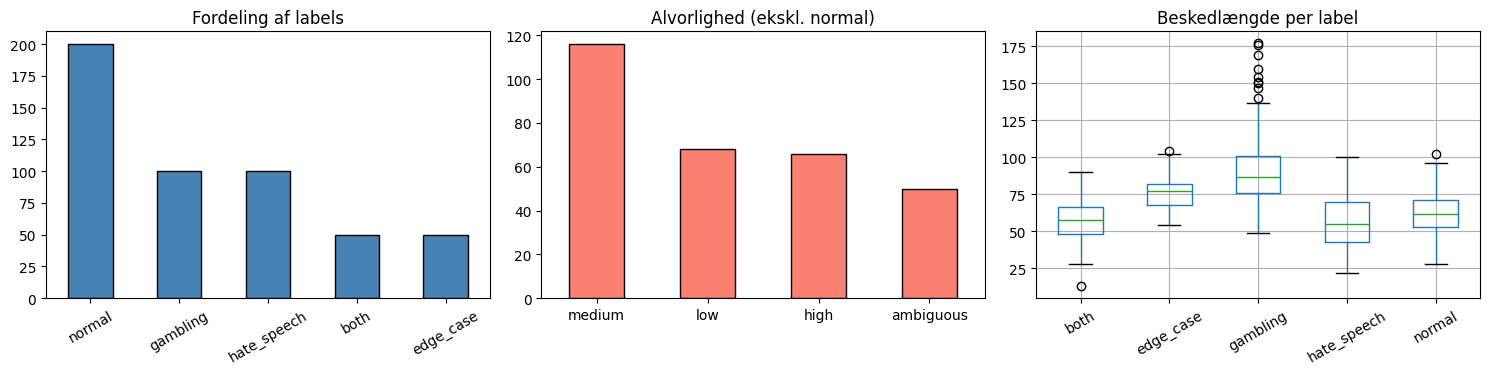

Gemt: dataset_overview.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False

df['msg_length'] = df['content'].str.len()
print("=== Datasæt statistik ===\n")
print(f"Antal beskeder: {len(df)}")
print(f"Antal unikke brugere: {df['user_id'].nunique()}")
print(f"\nGennemsnitlig beskedlængde per label (tegn):")
print(df.groupby('label')['msg_length'].mean().round(1).to_string())
print(f"\nEksempler per kategori:")
for label in df['label'].unique():
    eks = df[df['label'] == label]['content'].iloc[0]
    print(f"\n[{label}]: {eks[:100]}...")


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Labelfordeling
df['label'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Fordeling af labels')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

# 2. Alvorlighed
df[df['severity'] != 'none']['severity'].value_counts().plot(
    kind='bar', ax=axes[1], color='salmon', edgecolor='black'
)
axes[1].set_title('Alvorlighed (ekskl. normal)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

# 3. Beskedlængde per label
df.boxplot(column='msg_length', by='label', ax=axes[2])
axes[2].set_title('Beskedlængde per label')
axes[2].set_xlabel('')
plt.suptitle('')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gemt: dataset_overview.png")

## Fase 3 — AI-klassifikationssystem

Systemet klassificerer beskeder på to dimensioner (grimt sprog og ludomani) 
og udløser handlinger baseret på alvorlighedsniveau. Brugerhistorik indgår 
som kontekst for at fange mønstre over tid frem for kun at vurdere 
den enkelte besked isoleret.

Vi bygger systemet op trinvist:
- Trin 1: Simpelt klassifikationskald
- Trin 2: Parse svar til Python-objekt
- Trin 3: Handlingslogik
- Trin 4: Samlet funktion med brugerhistorik
- Trin 5: Kør på datasættet

### Trin 1

In [ ]:
# Trin 1: Simpelt klassifikationskald
besked = "tredje gang idag jeg indsætter. ved godt det er for meget"

prompt = f"""Du er et content moderation system for en dansk online casino-platform.

Analysér denne besked og klassificér adfærden:
"{besked}"

Returner KUN dette JSON:
{{
  "hate_speech_severity": "none/low/medium/high",
  "gambling_severity": "none/low/medium/high",
  "reasoning": "kort begrundelse på dansk"
}}"""

response = client.messages.create(
    model="claude-sonnet-4-6",
    max_tokens=300,
    messages=[{"role": "user", "content": prompt}]
)

print(response.content[0].text)

```json
{
  "hate_speech_severity": "none",
  "gambling_severity": "high",
  "reasoning": "Brugeren indsætter penge for tredje gang samme dag og erkender selv, at det er for meget. Dette indikerer manglende impulskontrol og selvbevidst problematisk spilleadfærd, hvilket er et klart tegn på potentielt ludomani. Bør udløse ansvarligt spil-intervention."
}
```


### Trin 2

In [20]:
# Trin 2: Parse svaret til Python-objekt

raw = response.content[0].text.strip()

# Fjern markdown-fences hvis de er der
if raw.startswith("```"):
    raw = raw.split("\n", 1)[1].rsplit("```", 1)[0].strip()

result = json.loads(raw)

print(f"Grimt sprog: {result['hate_speech_severity']}")
print(f"Ludomani:    {result['gambling_severity']}")
print(f"Begrundelse: {result['reasoning']}")

Grimt sprog: none
Ludomani:    high
Begrundelse: Brugeren indsætter penge for tredje gang samme dag og erkender selv, at det er for meget. Dette indikerer manglende impulskontrol og selvbevidst problematisk spilleadfærd, hvilket er et klart tegn på potentielt ludomani. Bør udløse ansvarligt spil-intervention.


### Trin 3

In [21]:
# Trin 3: Handlingslogik baseret på klassifikation

def determine_action(result: dict) -> list[str]:
    hate = result['hate_speech_severity']
    gamble = result['gambling_severity']
    
    actions = []
    
    if hate == 'low':
        actions.append("Send advarsel i chatforum")
    elif hate == 'medium':
        actions.append("Opret sag i backoffice (grimt sprog)")
    elif hate == 'high':
        actions.append("Bloker bruger fra chat")
    
    if gamble == 'low':
        actions.append("Send mail om ansvarligt spil")
    elif gamble == 'medium':
        actions.append("Opret sag i backoffice (ludomani)")
    elif gamble == 'high':
        actions.append("Sæt spilgrænser / selvudelukkelse")
    
    if not actions:
        actions.append("Ingen handling nødvendig")
    
    return actions

actions = determine_action(result)
for action in actions:
    print(action)

Sæt spilgrænser / selvudelukkelse


### Trin 4

In [ ]:
# Trin 4: Samlet funktion med brugerhistorik

def classify_message(content: str, user_history: list[str]) -> dict:
    
    if user_history:
        history_text = "\n".join([f"- {msg}" for msg in user_history[-5:]])
    else:
        history_text = "Ingen tidligere beskeder"
    
    prompt = f"""Du er et content moderation system for en dansk online casino-platform.

Analysér følgende besked og brugerens seneste historik:

BRUGERENS HISTORIK (seneste beskeder):
{history_text}

NY BESKED:
"{content}"

Returner KUN dette JSON:
{{
  "hate_speech_severity": "none/low/medium/high",
  "gambling_severity": "none/low/medium/high",
  "reasoning": "kort begrundelse på dansk"
}}"""

    response = client.messages.create(
        model="claude-sonnet-4-6",
        max_tokens=300,
        system="Du er et content moderation system. Returner kun valid JSON.",
        messages=[{"role": "user", "content": prompt}]
    )
    
    raw = response.content[0].text.strip()
    if raw.startswith("```"):
        raw = raw.split("\n", 1)[1].rsplit("```", 1)[0].strip()
    
    return json.loads(raw)

# Test med og uden historik
besked = "er lidt frustreret men fortsætter bare"

print("=== UDEN historik ===")
result_uden = classify_message(besked, [])
print(f"Ludomani: {result_uden['gambling_severity']}")
print(f"Begrundelse: {result_uden['reasoning']}\n")

print("=== MED historik ===")
historik = [
    "har tabt 2000 kr idag allerede",
    "okay prøver lige en gang til",
    "tredje gang idag jeg indsætter"
]
result_med = classify_message(besked, historik)
print(f"Ludomani: {result_med['gambling_severity']}")
print(f"Begrundelse: {result_med['reasoning']}")

=== UDEN historik ===
Ludomani: low
Begrundelse: Beskeden udtrykker frustration og en intention om at fortsætte med at spille. Der er ingen hadefuld tale. Frustrationen kombineret med ønsket om at fortsætte kan være et svagt tegn på problematisk spilleadfærd, men er ikke alarmerende i sig selv uden yderligere kontekst.

=== MED historik ===
Ludomani: high
Begrundelse: Brugeren viser klare tegn på problematisk spilleadfærd: tre indskud samme dag, tab på 2000 kr, frustration kombineret med fortsættelse af spil. Dette mønster indikerer chasing losses, som er et alvorligt advarselstegn for ludomani. Kræver øjeblikkelig intervention.


### Trin 5

In [23]:
# Trin 5: Kør systemet på et udsnit af datasættet

def process_message(row, df):
    # Hent brugerens historik (tidligere beskeder fra samme bruger)
    history = df[
        (df['user_id'] == row['user_id']) & 
        (df['msg_id'] < row['msg_id'])
    ]['content'].tolist()[-5:]
    
    classification = classify_message(row['content'], history)
    actions = determine_action(classification)
    
    return {
        'msg_id':               row['msg_id'],
        'user_id':              row['user_id'],
        'content':              row['content'],
        'true_label':           row['label'],
        'true_hate_speech':     row['hate_speech'],
        'true_gambling':        row['gambling'],
        'pred_hate_speech':     classification['hate_speech_severity'],
        'pred_gambling':        classification['gambling_severity'],
        'reasoning':            classification['reasoning'],
        'actions':              ', '.join(actions),
    }

# Kør på 100 beskeder: 20 per label
sample = df.groupby('label').apply(
    lambda x: x.sample(20, random_state=42)
).reset_index(drop=True)

print(f"Kører klassifikation på {len(sample)} beskeder...")
results = []

for i, row in sample.iterrows():
    result = process_message(row, df)
    results.append(result)
    if (len(results)) % 10 == 0:
        print(f"  {len(results)}/100 færdig...")

results_df = pd.DataFrame(results)
results_df.to_csv("classification_results.csv", index=False)
print("Færdig! Gemt: classification_results.csv")
print(results_df[['true_label', 'pred_hate_speech', 'pred_gambling', 'actions']].head(10))

/var/folders/yt/3hzr6y7d529d_5n4k1_3xlgr0000gn/T/ipykernel_14603/273799645.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample = df.groupby('label').apply(


Kører klassifikation på 100 beskeder...
  10/50 færdig...
  20/50 færdig...
  30/50 færdig...
  40/50 færdig...
  50/50 færdig...
  60/50 færdig...
  70/50 færdig...
  80/50 færdig...
  90/50 færdig...
  100/50 færdig...
Færdig! Gemt: classification_results.csv
  true_label pred_hate_speech pred_gambling                            actions
0       both             none          none           Ingen handling nødvendig
1       both             none           low       Send mail om ansvarligt spil
2       both             none        medium  Opret sag i backoffice (ludomani)
3       both              low          none          Send advarsel i chatforum
4       both             none          none           Ingen handling nødvendig
5       both             none           low       Send mail om ansvarligt spil
6       both             none           low       Send mail om ansvarligt spil
7       both             none          none           Ingen handling nødvendig
8       both             no

### Fase 3B — Baseline model (TF-IDF + Logistisk Regression)

In [26]:
# Imports
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, f1_score, classification_report

In [28]:
# Datasplit
X = df['content']  # teksten
y = df['label']  # hvad vi vil forudsige

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=100, random_state=42)

In [ ]:
#TF-IDF

vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [31]:
# Logistic regression

clf = LogisticRegression(random_state=42).fit(X_train_tfidf, y_train)

y_train_pred = clf.predict(X_train_tfidf)
y_test_pred = clf.predict(X_test_tfidf)

print("Train accuracy:", clf.score(X_train_tfidf, y_train))
print("Test accuracy:", clf.score(X_test_tfidf, y_test))

Train accuracy: 0.8175
Test accuracy: 0.74


## Fase 4 - Performance evaluering
### 4a - Baseline (TF-IDF + Logistisk Regression)

In [32]:
# Classfication report:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

        both       0.00      0.00      0.00         6
   edge_case       0.00      0.00      0.00         8
    gambling       0.71      0.85      0.77        20
 hate_speech       0.92      0.65      0.76        17
      normal       0.73      0.94      0.82        49

    accuracy                           0.74       100
   macro avg       0.47      0.49      0.47       100
weighted avg       0.66      0.74      0.69       100



/Users/carlemil112/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/carlemil112/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/carlemil112/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

#### Confusion Matrix — Baseline

Confusion matrix viser præcist hvilke klasser modellen forveksler. 
Rækker er sande labels, kolonner er forudsagte labels. 
Diagonalen er korrekte klassifikationer.

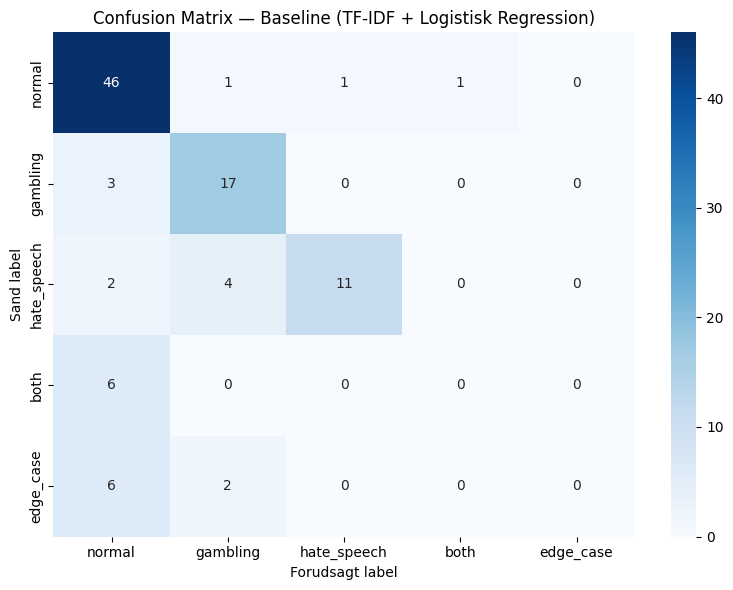

In [40]:
import seaborn as sns

cm = confusion_matrix(y_test, y_test_pred, labels=['normal', 'gambling', 'hate_speech', 'both', 'edge_case'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['normal', 'gambling', 'hate_speech', 'both', 'edge_case'],
            yticklabels=['normal', 'gambling', 'hate_speech', 'both', 'edge_case'])
plt.title('Confusion Matrix — Baseline (TF-IDF + Logistisk Regression)')
plt.ylabel('Sand label')
plt.xlabel('Forudsagt label')
plt.tight_layout()
plt.savefig('confusion_matrix_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

Baseline-modellen er god til at identificere normale beskeder (46/49 korrekte) 
samt gambling og hate_speech på basisniveau. Den forudsiger aldrig "both" eller 
"edge_case" korrekt — alle ender klassificeret som normal. Det skyldes at disse 
kategorier er underrepræsenterede i træningsdata og sprogligt overlapper med de andre.

### 4b - LLM Klassifikator — Performance

In [34]:
results_df = pd.read_csv("classification_results.csv")

#As LLM predicts two columns - hate_speech and gambling, it needs conversion to same format for fair comparison.
def convert_output(pred_hate, pred_gambling):
    if pred_hate != "none" and pred_gambling != "none":
        prediction = "both"
    elif pred_hate != "none" and pred_gambling == "none":
        prediction = "hate_speech"
    elif pred_hate == "none" and pred_gambling != "none":
        prediction = "gambling"
    else:
        prediction = "normal"

    return prediction


results_df['pred_label'] = results_df.apply(
    lambda row: convert_output(row['pred_hate_speech'], row['pred_gambling']), axis=1
)

print(classification_report(results_df['true_label'], results_df['pred_label']))

              precision    recall  f1-score   support

        both       0.00      0.00      0.00        20
   edge_case       0.00      0.00      0.00        20
    gambling       0.25      0.90      0.39        20
 hate_speech       0.86      0.30      0.44        20
      normal       0.40      0.20      0.27        20

    accuracy                           0.28       100
   macro avg       0.30      0.28      0.22       100
weighted avg       0.30      0.28      0.22       100



/Users/carlemil112/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/carlemil112/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/carlemil112/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

#### Confusion Matrix - LLM

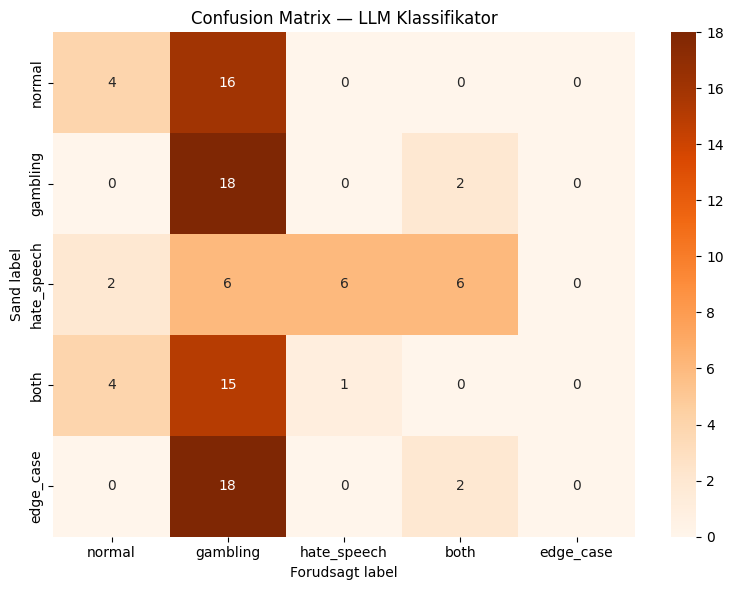

In [41]:
cm_llm = confusion_matrix(results_df['true_label'], results_df['pred_label'], 
                          labels=['normal', 'gambling', 'hate_speech', 'both', 'edge_case'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_llm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['normal', 'gambling', 'hate_speech', 'both', 'edge_case'],
            yticklabels=['normal', 'gambling', 'hate_speech', 'both', 'edge_case'])
plt.title('Confusion Matrix — LLM Klassifikator')
plt.ylabel('Sand label')
plt.xlabel('Forudsagt label')
plt.tight_layout()
plt.savefig('confusion_matrix_llm.png', dpi=150, bbox_inches='tight')
plt.show()

LLM'en klassificerer langt de fleste beskeder som gambling, også normale beskeder 
og edge cases. Det skyldes at gambling-signaler er sprogligt lettere at fange 
(konkrete ord som "tab", "indsætter", "vinder"), mens hate_speech kræver mere 
kontekstuel fortolkning.

Særligt bemærkelsesværdigt:
- 16/20 normale beskeder klassificeres fejlagtigt som gambling (høj false positive rate)
- edge_case ender næsten udelukkende som gambling (18/20)
- both fanges delvist: 15/20 klassificeres som gambling, men mister hate_speech-dimensionen

Dette bekræfter at LLM'en er stærk til at fange bekymrende spiladfærd, men 
overklassificerer gambling på bekostning af præcision.

### Observation: Direkte sammenligning er unfair mod LLM'en

LLM'en er ikke designet til at gætte vores syntetiske labels, den er designet 
til at vurdere alvorlighed og udløse handlinger. Når vi tvinger dens output ind 
i vores 5-klasse format mister vi information.

Eksempel: en "both"-besked hvor LLM'en korrekt fanger gambling-adfærd men ikke 
grimt sprog tæller som forkert, selvom systemet faktisk ville have udløst den 
rigtige handling.

En mere fair evaluering er derfor binær: fanger systemet problematisk adfærd 
overhovedet, uanset præcis hvilken underkategori?

### 4c — Sammenligning

Begge systemer evalueres binært (problematisk vs. normal) da LLM'ens 
output ikke direkte kan sammenlignes med vores 5-klasse labels.

In [35]:
# Binær evaluering: problematisk vs. ikke-problematisk
results_df['true_binary'] = results_df['true_label'].apply(
    lambda x: 'problematisk' if x != 'normal' else 'normal'
)
results_df['pred_binary'] = results_df['pred_label'].apply(
    lambda x: 'problematisk' if x != 'normal' else 'normal'
)

print(classification_report(results_df['true_binary'], results_df['pred_binary']))

              precision    recall  f1-score   support

      normal       0.40      0.20      0.27        20
problematisk       0.82      0.93      0.87        80

    accuracy                           0.78       100
   macro avg       0.61      0.56      0.57       100
weighted avg       0.74      0.78      0.75       100



In [36]:
# Binær evaluering for baseline model:
y_test_df = pd.DataFrame({'true_label': y_test, 'pred_label': y_test_pred})

y_test_df['true_binary'] = y_test_df['true_label'].apply(
    lambda x: 'problematisk' if x != 'normal' else 'normal'
)
y_test_df['pred_binary'] = y_test_df['pred_label'].apply(
    lambda x: 'problematisk' if x != 'normal' else 'normal'
)

print(classification_report(y_test_df['true_binary'], y_test_df['pred_binary']))

              precision    recall  f1-score   support

      normal       0.73      0.94      0.82        49
problematisk       0.92      0.67      0.77        51

    accuracy                           0.80       100
   macro avg       0.82      0.80      0.80       100
weighted avg       0.83      0.80      0.80       100



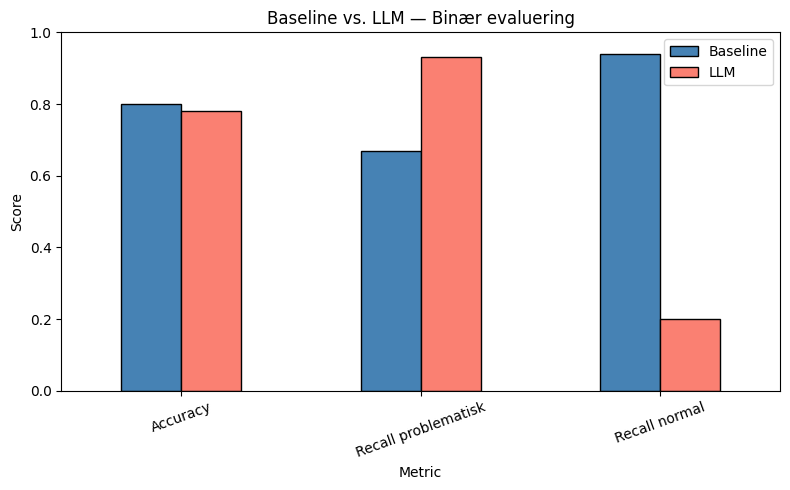

In [38]:
# Dataframe til sammenligning
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Recall problematisk', 'Recall normal'],
    'Baseline': [0.80, 0.67, 0.94],
    'LLM':      [0.78, 0.93, 0.20]
})

comparison.set_index('Metric').plot(kind='bar', figsize=(8, 5), color=['steelblue', 'salmon'], edgecolor='black')
plt.title('Baseline vs. LLM — Binær evaluering')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Fase 5 — Refleksion

### Kontekstvinduets betydning
Brugerhistorik er afgørende for at fange mønstre over tid. En enkelt besked 
som "er lidt frustreret men fortsætter bare" klassificeres som lav risiko uden 
kontekst, men som høj risiko (chasing losses) når historikken viser gentagne 
indskud og store tab samme dag. Kontekstvinduet er sat til de 5 seneste beskeder 
— et større vindue ville fange længerevarende mønstre, men øge latency og pris.

### Håndtering af edge cases
Sarkasme, ironi og slang er systemets svageste punkt. En besked som "fedt, endnu 
et tab" kan være ironisk frustration eller ægte bekymrende adfærd. LLM'en håndterer 
dette bedre end baseline fordi den forstår kontekst, men confusion matrix viser 
at edge cases stadig er svære — 18/20 ender som gambling uanset den faktiske nuance.

### False positives vs. false negatives
De to kategorier har asymmetriske konsekvenser:

**Grimt sprog:** En false positive (uskyldig bruger advares) koster kundeoplevelse 
og tillid. En false negative (grov chikane misses) skader andre brugere. 
Her er præcision vigtig — baseline foretrækkes.

**Ludomani:** En false positive (bruger får mail om ansvarligt spil) er harmløs. 
En false negative (bruger med spilleproblemer misses) kan have alvorlige konsekvenser 
for brugerens velfærd og CEGOs ansvar over for ansvarligt spil-regulering. 
Her er recall vigtig — LLM foretrækkes.

### Forbedringer med mere tid
- Rigtige chatdata frem for syntetisk genereret data
- Finjustering af prompt baseret på fejlkategorier fra confusion matrix
- Ensemble-tilgang: baseline til grove kategorier, LLM til edge cases
- Aktiv læring: menneskelig review af usikre klassifikationer

## Konklusion

LLM'en er markant bedre til at fange problematisk adfærd (recall 0.93 vs. 0.67), 
men på bekostning af mange false positives på normale beskeder (recall 0.20 vs. 0.94).

Baseline er mere præcis og konservativ, men misser en tredjedel af problematiske beskeder.

**Anbefaling til produktion:**
- Ludomani: LLM foretrækkes — en missed detection er potentielt meget skadelig
- Grimt sprog: Baseline eller kombination — false positives koster kundeoplevelse
- Hastighed: Baseline er markant hurtigere og billigere at skalere